<a href="https://colab.research.google.com/github/ifeiwuch/ai201-project3-takemeter/blob/main/Copy_of_ai201_project3_takemeter_starter_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [17]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [18]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [19]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "neutral":  0,   # ← Replace with your first label
    "bearish":  1,   # ← Replace with your second label
    "bullish":  2,   # ← Replace with your third label (remove if you have 2 labels)
    # "fourth_label": 3,  # ← Uncomment if you have a fourth label
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'neutral': 0, 'bearish': 1, 'bullish': 2}
Number of labels: 3


In [20]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving reddit_investing_sentiment_data.csv to reddit_investing_sentiment_data (1).csv
Uploaded: reddit_investing_sentiment_data (1).csv


In [21]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label', 'notes']
Total examples: 200

Label distribution:
label
neutral    77
bearish    64
bullish    59
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [44]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 140 examples
Validation: 30 examples
Test: 30 examples

Train label distribution:
label
neutral    54
bearish    45
bullish    41
Name: count, dtype: int64

Test label distribution:
label
neutral    12
bearish     9
bullish     9
Name: count, dtype: int64


In [45]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/140 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [51]:
# Run this in a new cell to check your data quality
print("Label distribution:")
print(df['label'].value_counts())
print()
print("Sample texts per label:")
for label in df['label'].unique():
    sample = df[df['label']==label]['text'].iloc[0]
    print(f"\n{label}: {sample[:200]}")
print()
print("Any empty texts?", df['text'].isna().sum())
print("Any duplicate texts?", df['text'].duplicated().sum())

Label distribution:
label
neutral    77
bearish    64
bullish    59
Name: count, dtype: int64

Sample texts per label:

neutral: What is your worst investing mistake? I’ve made one
Back in early 2023 an old coworker told me to invest in SOXL. So I put $500 in for what was $15 a share at the time… then sold it like a month late

bullish: NBIS and RKLB getting listed on June 22
NBIS and RKLB getting listed on June 22

I'm wondering what's the general pattern when stocks are getting listed, if we hold NBIS and RKLB, will it tend to go u

bearish: I know nothing about ACN's stock price but I have observed a lot of post-drop earnings and then a fairly quick reversion. Accenture seems a little worse because it came out with negative info on their

Any empty texts? 0
Any duplicate texts? 0


In [52]:
df['text_length'] = df['text'].str.len()
print(df.groupby('label')['text_length'].describe())
print()
print("Texts under 100 characters:")
print(df[df['text_length'] < 100][['text', 'label']])

         count        mean         std    min     25%    50%      75%     max
label                                                                        
bearish   64.0  990.218750  825.389460  122.0  434.25  654.5  1267.25  3789.0
bullish   59.0  691.949153  588.683728   93.0  326.00  510.0   826.00  2916.0
neutral   77.0  715.727273  503.016470  109.0  382.00  528.0   890.00  2564.0

Texts under 100 characters:
                                                 text    label
13  Oil ETFs aren't good long term holds, way too ...  bullish


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [47]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model loaded: ProsusAI/finbert
Output labels: 3


In [48]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [50]:
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3, # Changed from 10 to 3 to prevent overfitting on small datasets
    per_device_train_batch_size=16, # Changed from 8 to 16, standard for T4 GPU
    per_device_eval_batch_size=32,
    learning_rate=2e-5, # Changed from 5e-6 to 2e-5, standard starting point for BERT fine-tuning
    weight_decay=0.01,
    warmup_steps=50, # Changed from 20 to 50, standard default
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.485785,0.266667
2,0.494430,1.624326,0.300000
3,0.441675,1.776605,0.333333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [53]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.433

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

     neutral       0.54      0.58      0.56        12
     bearish       0.44      0.44      0.44         9
     bullish       0.25      0.22      0.24         9

    accuracy                           0.43        30
   macro avg       0.41      0.42      0.41        30
weighted avg       0.42      0.43      0.43        30



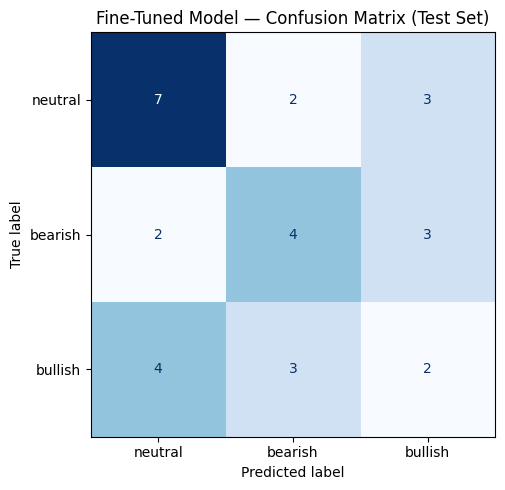

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [54]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [55]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 17 / 30

--- #1 ---
Text:      Increased AI bear sentiment and rotation into defensives is a contrarian bull signal, not confirmation of a top
The last two weeks I've seen more "AI bubble" posts, YouTube videos, and finance thread...
True:      bearish
Predicted: bullish  (confidence: 0.41)

--- #2 ---
Text:      This week: May CPI inflation will break above 4% and ECB will hike on Thurday
For those wondering if markets have more room to fall..

On Wednesday US CPI data for the month of May will be released...
True:      bearish
Predicted: neutral  (confidence: 0.93)

--- #3 ---
Text:      Over the long-term, the market cap of a company is supposed to represent the present value of the expected free cash flows from the company. An individual stock is the market cap, sliced however small...
True:      neutral
Predicted: bullish  (confidence: 0.63)

--- #4 ---
Text:      Why the Bitcoin Market is a Ticking Time Bomb for the Most Spectacular Crash in History
The reason 

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [56]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get('GROQ_API_KEY').strip()
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (🔑, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [57]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are classifying posts from r/investing on Reddit.
Assign each post to exactly one of the following categories.

bullish: The post expresses a positive outlook on a stock, sector, or the market broadly — expecting prices to rise, recommending buying, or highlighting reasons for optimism.
Example: "NVDA is still undervalued at these levels. AI infrastructure demand isn't slowing down and they have no real competition for another 2-3 years. Adding more here."

bearish: The post expresses a negative outlook — expecting prices to fall, recommending selling or avoiding, or highlighting risks and reasons for pessimism.
Example: "The Fed isn't cutting until inflation is actually dead. Anyone pricing in rate cuts for Q1 is going to get wrecked. Stay in cash."

neutral: The post asks a question, shares information without a directional thesis, or presents balanced analysis without a clear bullish or bearish conclusion.
Example: "Can someone explain how bond yields affect equity valuations? Trying to understand the relationship better."

Respond with ONLY the label name.
Do not explain your reasoning.

Valid labels:
bullish
bearish
neutral
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1152 characters


In [58]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 30 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/30 complete...
  20/30 complete...
  30/30 complete...


In [59]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.867  (evaluated on 30/30 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

     neutral       0.85      0.92      0.88        12
     bearish       0.88      0.78      0.82         9
     bullish       0.89      0.89      0.89         9

    accuracy                           0.87        30
   macro avg       0.87      0.86      0.86        30
weighted avg       0.87      0.87      0.87        30



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [60]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.867
Fine-tuned DistilBERT                  0.433
---------------------------------------------

Fine-tuning regression: 0.433

Use these numbers in your README evaluation report.


In [61]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
